In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from transformers import AutoImageProcessor, ViTForImageClassification

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
dataset = load_dataset("AI-Lab-Makerere/beans")

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})
Train size: 1034
Validation size: 133
Test size: 128


In [3]:
label_names = dataset["train"].features["labels"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print("Class names:", label_names)
print("id2label:", id2label)
print("label2id:", label2id)

Class names: ['angular_leaf_spot', 'bean_rust', 'healthy']
id2label: {0: 'angular_leaf_spot', 1: 'bean_rust', 2: 'healthy'}
label2id: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}


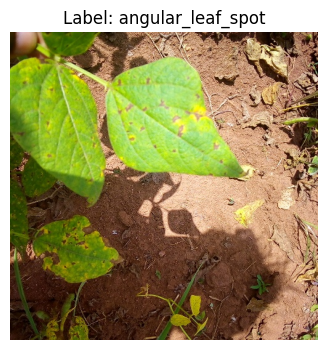

In [4]:
sample = dataset["train"][0]
image = sample["image"]
label = sample["labels"]

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {label_names[label]}")
plt.show()

### Load image processor

In [5]:
model_name = "google/vit-base-patch16-224"
image_processor = AutoImageProcessor.from_pretrained(model_name)

print(image_processor)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [6]:
encoded_image = image_processor(image, return_tensors="pt")

print("Keys:", encoded_image.keys())
print("pixel_values shape:", encoded_image["pixel_values"].shape)
print(encoded_image["pixel_values"][0, :, :3, :3])

Keys: KeysView({'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255]

### Custom Dataset class

In [7]:
class BeansDataset(Dataset):
    def __init__(self, hf_dataset, image_processor):
        self.dataset = hf_dataset
        self.image_processor = image_processor
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        item = self.dataset[index]
        
        image = item["image"].convert("RGB")
        label = item["labels"]
        
        encoding = self.image_processor(image, return_tensors="pt")
        
        return {
            "pixel_values" : encoding["pixel_values"].squeeze(0),
            "labels" : torch.tensor(label, dtype=torch.long)
        }

In [8]:
train_dataset = BeansDataset(dataset["train"], image_processor)
val_dataset = BeansDataset(dataset["validation"], image_processor)
test_dataset = BeansDataset(dataset["test"], image_processor)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 1034
Validation dataset: 133
Test dataset: 128


In [9]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [10]:
batch = next(iter(train_loader))

print("pixel_values shape:", batch["pixel_values"].shape)
print("labels shape:", batch["labels"].shape)
print("labels:", batch["labels"])

pixel_values shape: torch.Size([8, 3, 224, 224])
labels shape: torch.Size([8])
labels: tensor([0, 0, 2, 1, 2, 1, 1, 1])


### Load pretrained ViT for classification

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

print("Device:", device)
print(model.config)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Device: cuda
ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "dtype": "float32",
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "angular_leaf_spot",
    "1": "bean_rust",
    "2": "healthy"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "angular_leaf_spot": 0,
    "bean_rust": 1,
    "healthy": 2
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "transformers_version": "5.0.0"
}



In [12]:
small_batch = next(iter(train_loader))

pixel_values = small_batch["pixel_values"].to(device)
labels = small_batch["labels"].to(device)

outputs = model(pixel_values=pixel_values, labels=labels)

print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)
print("Logits:")
print(outputs.logits)

Loss: 1.293161153793335
Logits shape: torch.Size([8, 3])
Logits:
tensor([[-0.6631,  0.2166,  0.1893],
        [-0.6718,  0.1118,  0.4241],
        [-0.5187,  0.0930,  0.5751],
        [-0.5398,  0.0414, -0.2426],
        [-0.5584,  0.0852,  0.2782],
        [-0.7822,  0.1096,  0.1030],
        [-0.8257,  0.1463, -0.1327],
        [-0.8351, -0.2527,  0.2886]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


### Train function

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

### Evaluation function

In [14]:
def evaluate(model, dataloader, device):
    model.eval()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds